# Combine ML + Transformer Results for Thesis (Kaggle)

This notebook:
- loads result CSVs from your two notebook output folders inside `/kaggle/input`
- removes **BanglaBERT (Calibrated)** and **XLM-R (Calibrated)**
- creates final combined **test**, **validation**, and **main** result tables
- creates extra comparison tables for thesis writing
- saves thesis-friendly figures into `/kaggle/working/final_combined_outputs`

## Expected input files
From your **classical ML** notebook output:
- `test_results.csv`
- `validation_results.csv`

From your **transformer** notebook output:
- `test_results_long_format.csv`
- `validation_results_long_format.csv`

In [18]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_DIR = Path('/kaggle/working/final_combined_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('INPUT_ROOT :', INPUT_ROOT)
print('OUTPUT_DIR :', OUTPUT_DIR)

INPUT_ROOT : /kaggle/input
OUTPUT_DIR : /kaggle/working/final_combined_outputs


In [19]:
# Automatically find the needed files inside /kaggle/input
needed_files = {
    'ml_test': 'test_results.csv',
    'ml_val': 'validation_results.csv',
    'tr_test': 'test_results_long_format.csv',
    'tr_val': 'validation_results_long_format.csv',
}

found = {}
for key, filename in needed_files.items():
    matches = list(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'Could not find {filename} inside /kaggle/input')

    # prefer likely folders if they exist
    if key.startswith('ml_'):
        preferred = [m for m in matches if 'classical' in str(m).lower() or 'ml' in str(m).lower()]
    else:
        preferred = [m for m in matches if 'transform' in str(m).lower() or 'xlm' in str(m).lower() or 'bangla' in str(m).lower()]

    found[key] = preferred[0] if preferred else matches[0]

print('Using files:')
for k, v in found.items():
    print(f'{k:8} -> {v}')

Using files:
ml_test  -> /kaggle/input/datasets/prohorpaul/combine-results/classical_ml_outputs/test_results.csv
ml_val   -> /kaggle/input/datasets/prohorpaul/combine-results/classical_ml_outputs/validation_results.csv
tr_test  -> /kaggle/input/datasets/prohorpaul/combine-results/transformers_pipeline_outputs/test_results_long_format.csv
tr_val   -> /kaggle/input/datasets/prohorpaul/combine-results/transformers_pipeline_outputs/validation_results_long_format.csv


In [20]:
ml_test = pd.read_csv(found['ml_test'])
ml_val  = pd.read_csv(found['ml_val'])
tr_test = pd.read_csv(found['tr_test'])
tr_val  = pd.read_csv(found['tr_val'])

print('Shapes before filtering:')
print('ml_test :', ml_test.shape)
print('ml_val  :', ml_val.shape)
print('tr_test :', tr_test.shape)
print('tr_val  :', tr_val.shape)

print('ML test preview:')
display(ml_test.head())
print('Transformer test preview:')
display(tr_test.head())

Shapes before filtering:
ml_test : (4, 8)
ml_val  : (4, 8)
tr_test : (5, 8)
tr_val  : (5, 8)
ML test preview:


,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC,AP
0,Linear SVM,Test,0.890402,0.885676,0.896528,0.891069,0.952454,0.953108
1,Logistic Regression,Test,0.888359,0.883658,0.894486,0.889039,0.953119,0.953899
2,LightGBM,Test,0.868278,0.863087,0.875425,0.869213,0.944312,0.947958
3,Random Forest,Test,0.825051,0.822417,0.829135,0.825763,0.908812,0.913652


Transformer test preview:


,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC,AP
0,Calibrated Weighted Voting,Test,0.9299,0.9514,0.9061,0.9282,0.9819,0.9842
1,BanglaBERT,Test,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834
2,BanglaBERT (Calibrated),Test,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834
3,XLM-R,Test,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715
4,XLM-R (Calibrated),Test,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715


In [21]:
# Remove calibrated single-model rows that you do not want in the final comparison
remove_models = {'BanglaBERT (Calibrated)', 'XLM-R (Calibrated)'}

tr_test = tr_test[~tr_test['Model'].isin(remove_models)].copy()
tr_val  = tr_val[~tr_val['Model'].isin(remove_models)].copy()

print('Shapes after removing calibrated single-model rows:')
print('tr_test :', tr_test.shape)
print('tr_val  :', tr_val.shape)

print('Remaining transformer models:')
print(sorted(tr_test['Model'].unique()))

Shapes after removing calibrated single-model rows:
tr_test : (3, 8)
tr_val  : (3, 8)
Remaining transformer models:
['BanglaBERT', 'Calibrated Weighted Voting', 'XLM-R']


In [22]:
# Keep a common structure across ML + transformer tables
common_cols = ['Model', 'Split', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AP']

for df in (ml_test, ml_val):
    if 'AP' not in df.columns:
        df['AP'] = np.nan

# If Split column is missing anywhere, add it safely
if 'Split' not in ml_test.columns:
    ml_test['Split'] = 'Test'
if 'Split' not in ml_val.columns:
    ml_val['Split'] = 'Validation'
if 'Split' not in tr_test.columns:
    tr_test['Split'] = 'Test'
if 'Split' not in tr_val.columns:
    tr_val['Split'] = 'Validation'

combined_test = pd.concat([ml_test[common_cols], tr_test[common_cols]], ignore_index=True)
combined_val  = pd.concat([ml_val[common_cols], tr_val[common_cols]], ignore_index=True)
combined_main = pd.concat([combined_test, combined_val], ignore_index=True)

family_map = {
    'Logistic Regression': 'Classical ML',
    'Linear SVM': 'Classical ML',
    'SVM': 'Classical ML',
    'LightGBM': 'Classical ML',
    'Random Forest': 'Classical ML',
    'Decision Tree': 'Classical ML',
    'KNN': 'Classical ML',
    'kNN': 'Classical ML',
    'BanglaBERT': 'Transformer',
    'XLM-R': 'Transformer',
    'mBERT': 'Transformer',
    'mDeBERTaV3-Base': 'Transformer',
    'Calibrated Weighted Voting': 'Ensemble',
}

for df in (combined_test, combined_val, combined_main):
    df['Model_Family'] = df['Model'].map(family_map).fillna('Other')

combined_test = combined_test.sort_values(['F1', 'ROC_AUC', 'Accuracy'], ascending=[False, False, False]).reset_index(drop=True)
combined_val  = combined_val.sort_values(['F1', 'ROC_AUC', 'Accuracy'], ascending=[False, False, False]).reset_index(drop=True)
combined_main = combined_main.sort_values(['Split', 'F1', 'ROC_AUC', 'Accuracy'], ascending=[True, False, False, False]).reset_index(drop=True)

combined_test.to_csv(OUTPUT_DIR / 'combined_test_results.csv', index=False)
combined_val.to_csv(OUTPUT_DIR / 'combined_validation_results.csv', index=False)
combined_main.to_csv(OUTPUT_DIR / 'combined_main_results.csv', index=False)

print('Saved main CSV files:')
print(OUTPUT_DIR / 'combined_test_results.csv')
print(OUTPUT_DIR / 'combined_validation_results.csv')
print(OUTPUT_DIR / 'combined_main_results.csv')

Saved main CSV files:
/kaggle/working/final_combined_outputs/combined_test_results.csv
/kaggle/working/final_combined_outputs/combined_validation_results.csv
/kaggle/working/final_combined_outputs/combined_main_results.csv


In [23]:
print('Combined Test Results')
display(combined_test)

print('Combined Validation Results')
display(combined_val)

Combined Test Results


,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC,AP,Model_Family
0,Calibrated Weighted Voting,Test,0.929900,0.951400,0.906100,0.928200,0.981900,0.984200,Ensemble
1,BanglaBERT,Test,0.927800,0.955800,0.897200,0.925600,0.981000,0.983400,Transformer
2,XLM-R,Test,0.907400,0.927800,0.883600,0.905200,0.966500,0.971500,Transformer
3,Linear SVM,Test,0.890402,0.885676,0.896528,0.891069,0.952454,0.953108,Classical ML
4,Logistic Regression,Test,0.888359,0.883658,0.894486,0.889039,0.953119,0.953899,Classical ML
5,LightGBM,Test,0.868278,0.863087,0.875425,0.869213,0.944312,0.947958,Classical ML
6,Random Forest,Test,0.825051,0.822417,0.829135,0.825763,0.908812,0.913652,Classical ML


Combined Validation Results


,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC,AP,Model_Family
0,Calibrated Weighted Voting,Validation,0.936100,0.954600,0.915600,0.934700,0.983600,0.985700,Ensemble
1,BanglaBERT,Validation,0.932000,0.955500,0.906100,0.930200,0.983100,0.985000,Transformer
2,XLM-R,Validation,0.906800,0.925900,0.884400,0.904700,0.969800,0.972300,Transformer
3,Linear SVM,Validation,0.893197,0.908192,0.874830,0.891199,0.953475,0.956545,Classical ML
4,Logistic Regression,Validation,0.891837,0.904494,0.876190,0.890117,0.954117,0.957650,Classical ML
5,LightGBM,Validation,0.863265,0.864754,0.861224,0.862986,0.940654,0.945029,Classical ML
6,Random Forest,Validation,0.822449,0.822011,0.823129,0.822570,0.907523,0.910215,Classical ML


In [24]:
# Extra summary tables for thesis writing
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AP']

wide = combined_main.pivot(index='Model', columns='Split', values=metrics)
wide.columns = [f'{split}_{metric}' for metric, split in wide.columns]
wide = wide.reset_index()

# Ensure expected columns exist before averaging
for col in ['Test_F1', 'Validation_F1', 'Test_ROC_AUC', 'Validation_ROC_AUC']:
    if col not in wide.columns:
        wide[col] = np.nan

wide['Average_F1'] = wide[['Test_F1', 'Validation_F1']].mean(axis=1)
wide['Average_ROC_AUC'] = wide[['Test_ROC_AUC', 'Validation_ROC_AUC']].mean(axis=1)
wide['Model_Family'] = wide['Model'].map(family_map).fillna('Other')
wide = wide.sort_values(['Average_F1', 'Average_ROC_AUC'], ascending=[False, False]).reset_index(drop=True)
wide.to_csv(OUTPUT_DIR / 'combined_summary_wide.csv', index=False)

# Ranking tables
combined_test[['Model', 'Model_Family', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AP']]     .sort_values(['F1', 'ROC_AUC', 'Accuracy'], ascending=[False, False, False])     .reset_index(drop=True)     .to_csv(OUTPUT_DIR / 'test_model_ranking.csv', index=False)

combined_val[['Model', 'Model_Family', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AP']]     .sort_values(['F1', 'ROC_AUC', 'Accuracy'], ascending=[False, False, False])     .reset_index(drop=True)     .to_csv(OUTPUT_DIR / 'validation_model_ranking.csv', index=False)

# Validation - test gap analysis
comparison = combined_test[['Model'] + metrics].merge(
    combined_val[['Model'] + metrics], on='Model', suffixes=('_Test', '_Validation')
)
for m in metrics:
    comparison[f'{m}_Gap_ValMinusTest'] = comparison[f'{m}_Validation'] - comparison[f'{m}_Test']
comparison['Model_Family'] = comparison['Model'].map(family_map).fillna('Other')
comparison = comparison.sort_values('F1_Gap_ValMinusTest', ascending=False).reset_index(drop=True)
comparison.to_csv(OUTPUT_DIR / 'split_gap_analysis.csv', index=False)

print('Saved extra comparison CSV files.')
print('Wide Summary Table')
display(wide)
print('Gap Analysis Table')
display(comparison)

Saved extra comparison CSV files.
Wide Summary Table


,Model,Test_Accuracy,Validation_Accuracy,Test_Precision,Validation_Precision,Test_Recall,Validation_Recall,Test_F1,Validation_F1,Test_ROC_AUC,Validation_ROC_AUC,Test_AP,Validation_AP,Average_F1,Average_ROC_AUC,Model_Family
0,Calibrated Weighted Voting,0.929900,0.936100,0.951400,0.954600,0.906100,0.915600,0.928200,0.934700,0.981900,0.983600,0.984200,0.985700,0.931450,0.982750,Ensemble
1,BanglaBERT,0.927800,0.932000,0.955800,0.955500,0.897200,0.906100,0.925600,0.930200,0.981000,0.983100,0.983400,0.985000,0.927900,0.982050,Transformer
2,XLM-R,0.907400,0.906800,0.927800,0.925900,0.883600,0.884400,0.905200,0.904700,0.966500,0.969800,0.971500,0.972300,0.904950,0.968150,Transformer
3,Linear SVM,0.890402,0.893197,0.885676,0.908192,0.896528,0.874830,0.891069,0.891199,0.952454,0.953475,0.953108,0.956545,0.891134,0.952965,Classical ML
4,Logistic Regression,0.888359,0.891837,0.883658,0.904494,0.894486,0.876190,0.889039,0.890117,0.953119,0.954117,0.953899,0.957650,0.889578,0.953618,Classical ML
5,LightGBM,0.868278,0.863265,0.863087,0.864754,0.875425,0.861224,0.869213,0.862986,0.944312,0.940654,0.947958,0.945029,0.866099,0.942483,Classical ML
6,Random Forest,0.825051,0.822449,0.822417,0.822011,0.829135,0.823129,0.825763,0.822570,0.908812,0.907523,0.913652,0.910215,0.824166,0.908168,Classical ML


Gap Analysis Table


,Model,Accuracy_Test,Precision_Test,Recall_Test,F1_Test,ROC_AUC_Test,AP_Test,Accuracy_Validation,Precision_Validation,Recall_Validation,F1_Validation,ROC_AUC_Validation,AP_Validation,Accuracy_Gap_ValMinusTest,Precision_Gap_ValMinusTest,Recall_Gap_ValMinusTest,F1_Gap_ValMinusTest,ROC_AUC_Gap_ValMinusTest,AP_Gap_ValMinusTest,Model_Family
0,Calibrated Weighted Voting,0.929900,0.951400,0.906100,0.928200,0.981900,0.984200,0.936100,0.954600,0.915600,0.934700,0.983600,0.985700,0.006200,0.003200,0.009500,0.006500,0.001700,0.001500,Ensemble
1,BanglaBERT,0.927800,0.955800,0.897200,0.925600,0.981000,0.983400,0.932000,0.955500,0.906100,0.930200,0.983100,0.985000,0.004200,-0.000300,0.008900,0.004600,0.002100,0.001600,Transformer
2,Logistic Regression,0.888359,0.883658,0.894486,0.889039,0.953119,0.953899,0.891837,0.904494,0.876190,0.890117,0.954117,0.957650,0.003477,0.020836,-0.018296,0.001078,0.000998,0.003751,Classical ML
3,Linear SVM,0.890402,0.885676,0.896528,0.891069,0.952454,0.953108,0.893197,0.908192,0.874830,0.891199,0.953475,0.956545,0.002796,0.022516,-0.021698,0.000130,0.001021,0.003437,Classical ML
4,XLM-R,0.907400,0.927800,0.883600,0.905200,0.966500,0.971500,0.906800,0.925900,0.884400,0.904700,0.969800,0.972300,-0.000600,-0.001900,0.000800,-0.000500,0.003300,0.000800,Transformer
5,Random Forest,0.825051,0.822417,0.829135,0.825763,0.908812,0.913652,0.822449,0.822011,0.823129,0.822570,0.907523,0.910215,-0.002602,-0.000406,-0.006006,-0.003193,-0.001290,-0.003437,Classical ML
6,LightGBM,0.868278,0.863087,0.875425,0.869213,0.944312,0.947958,0.863265,0.864754,0.861224,0.862986,0.940654,0.945029,-0.005012,0.001667,-0.014201,-0.006227,-0.003658,-0.002928,Classical ML


In [25]:
# Plot style
plt.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
})

plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AP']
model_order = wide['Model'].tolist()

def get_split_df(split_name):
    source = combined_test if split_name == 'Test' else combined_val
    return source.set_index('Model').loc[model_order].reset_index()

def annotate_heatmap(ax, data, fmt='.3f'):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = '' if pd.isna(val) else format(val, fmt)
            ax.text(j, i, text, ha='center', va='center', fontsize=9)

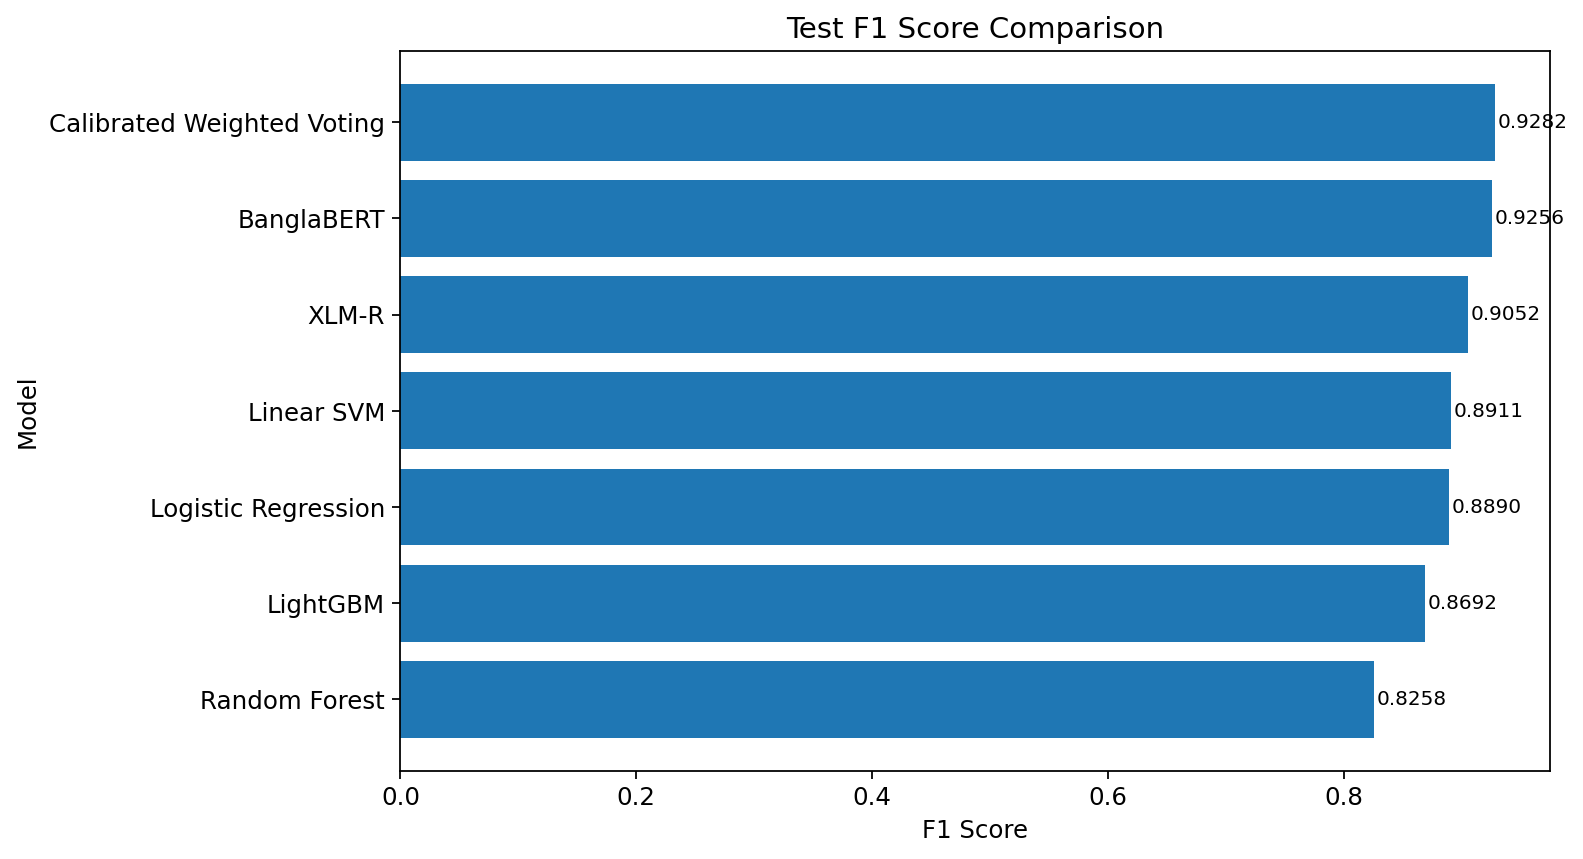

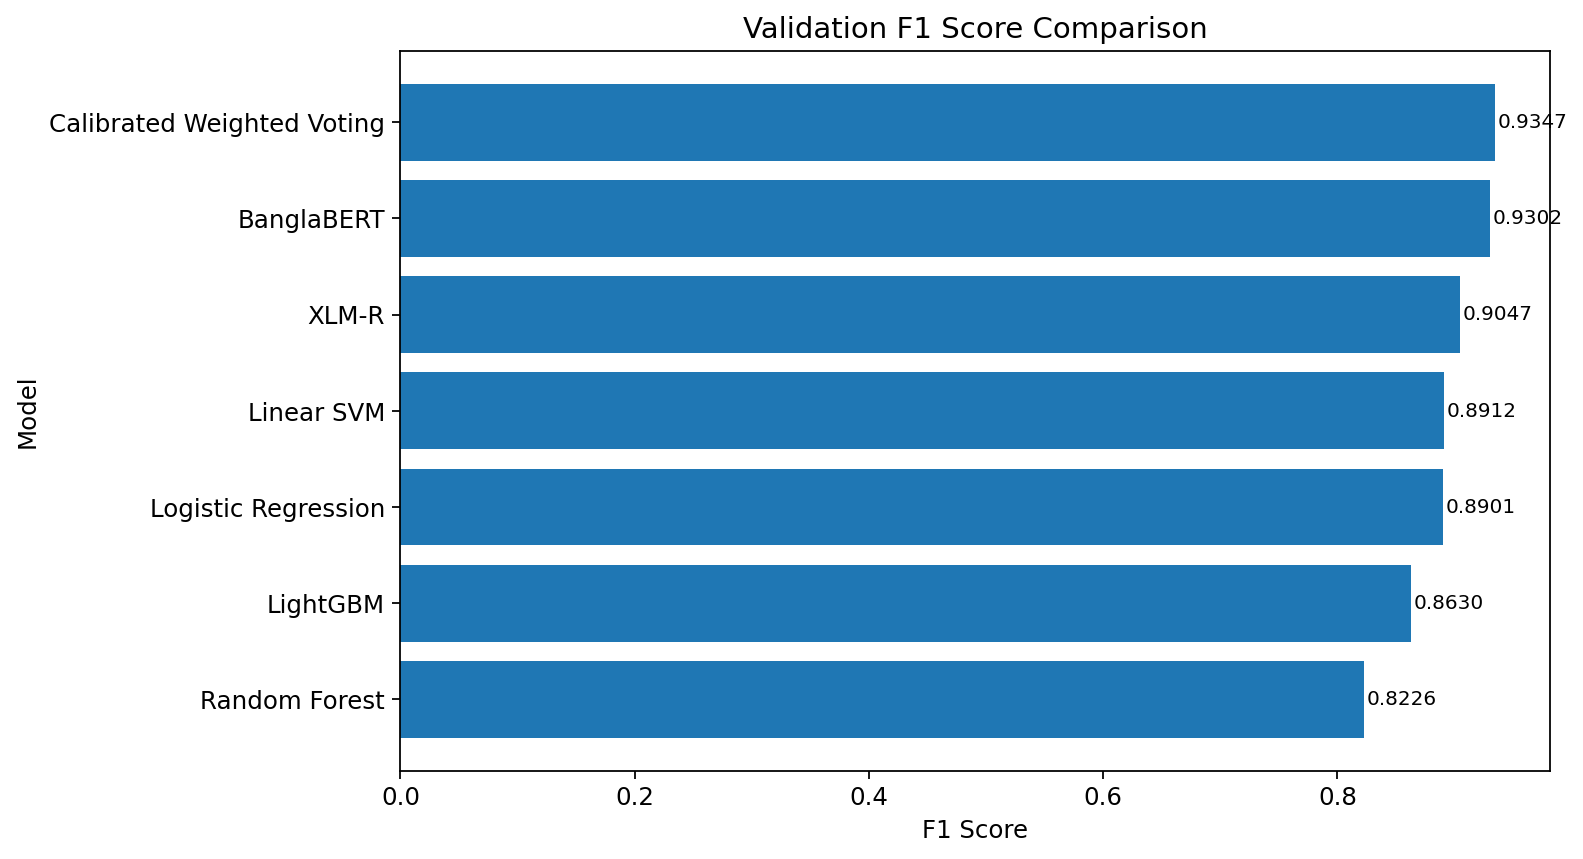

In [26]:
# 1) F1 horizontal bar charts
for split_name, df in [('Test', combined_test.copy()), ('Validation', combined_val.copy())]:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    plot_df = df.sort_values('F1', ascending=True)
    ax.barh(plot_df['Model'], plot_df['F1'])
    ax.set_title(f'{split_name} F1 Score Comparison')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('Model')
    for i, v in enumerate(plot_df['F1']):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{split_name.lower()}_f1_bar_chart.png', bbox_inches='tight')
    plt.show()

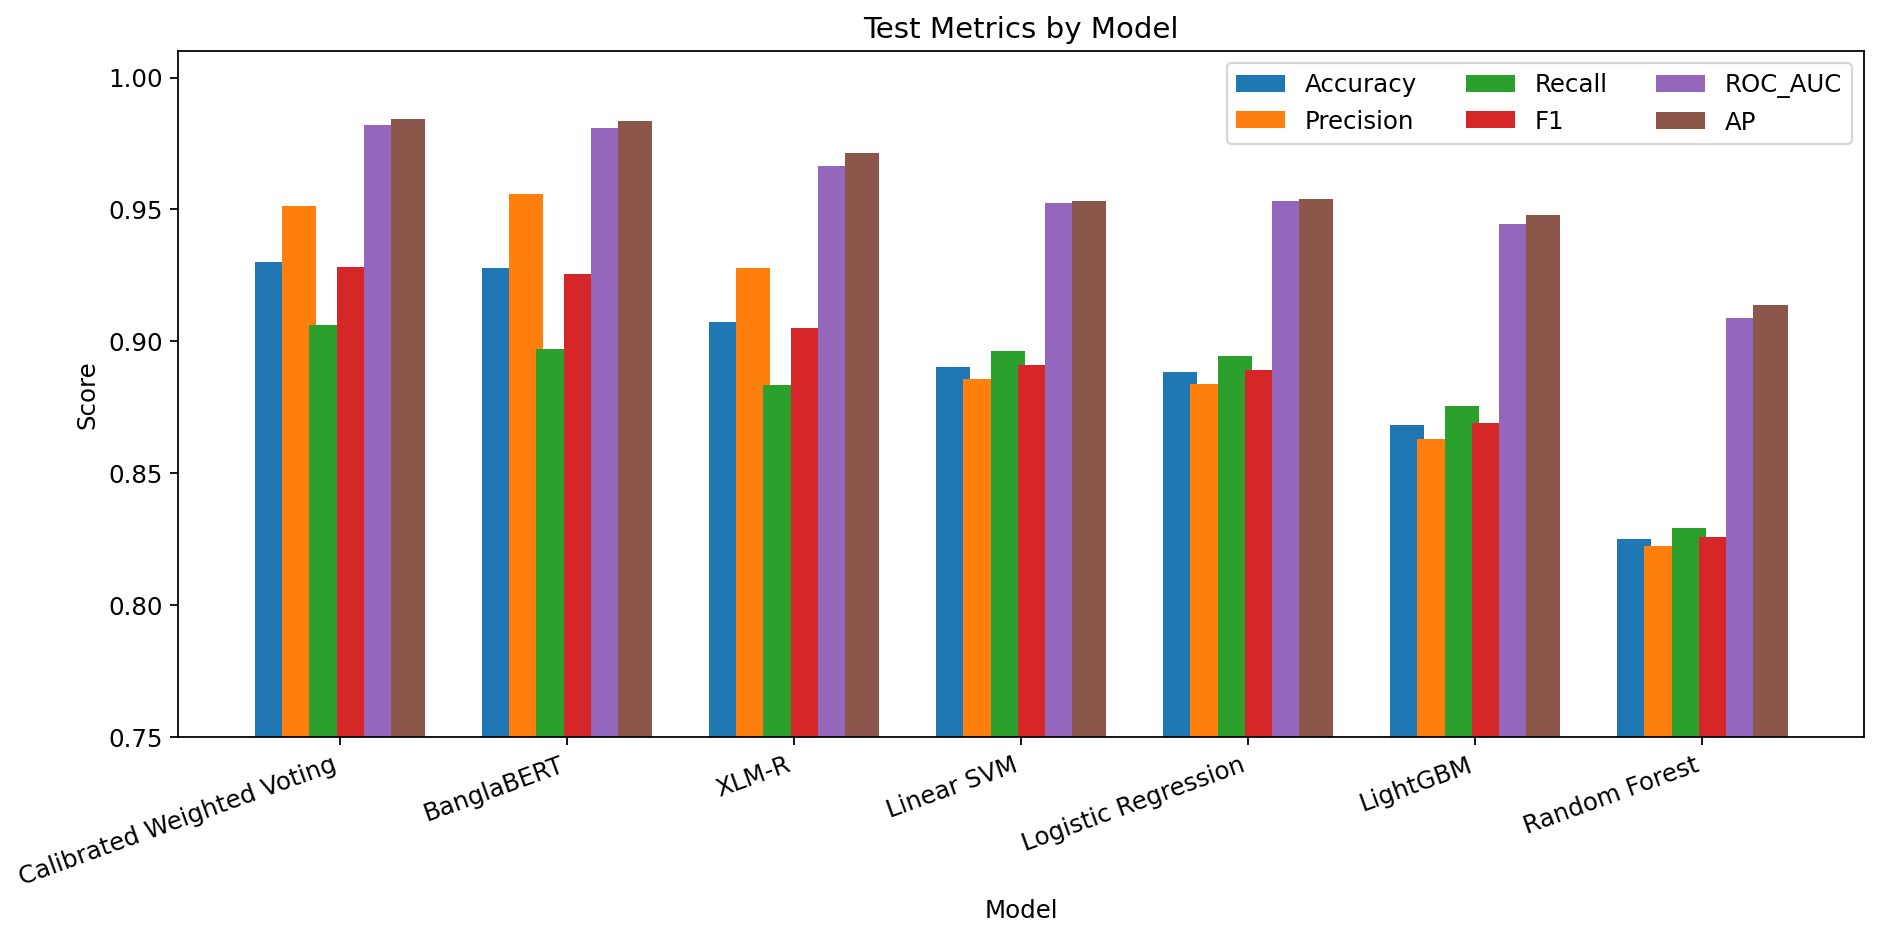

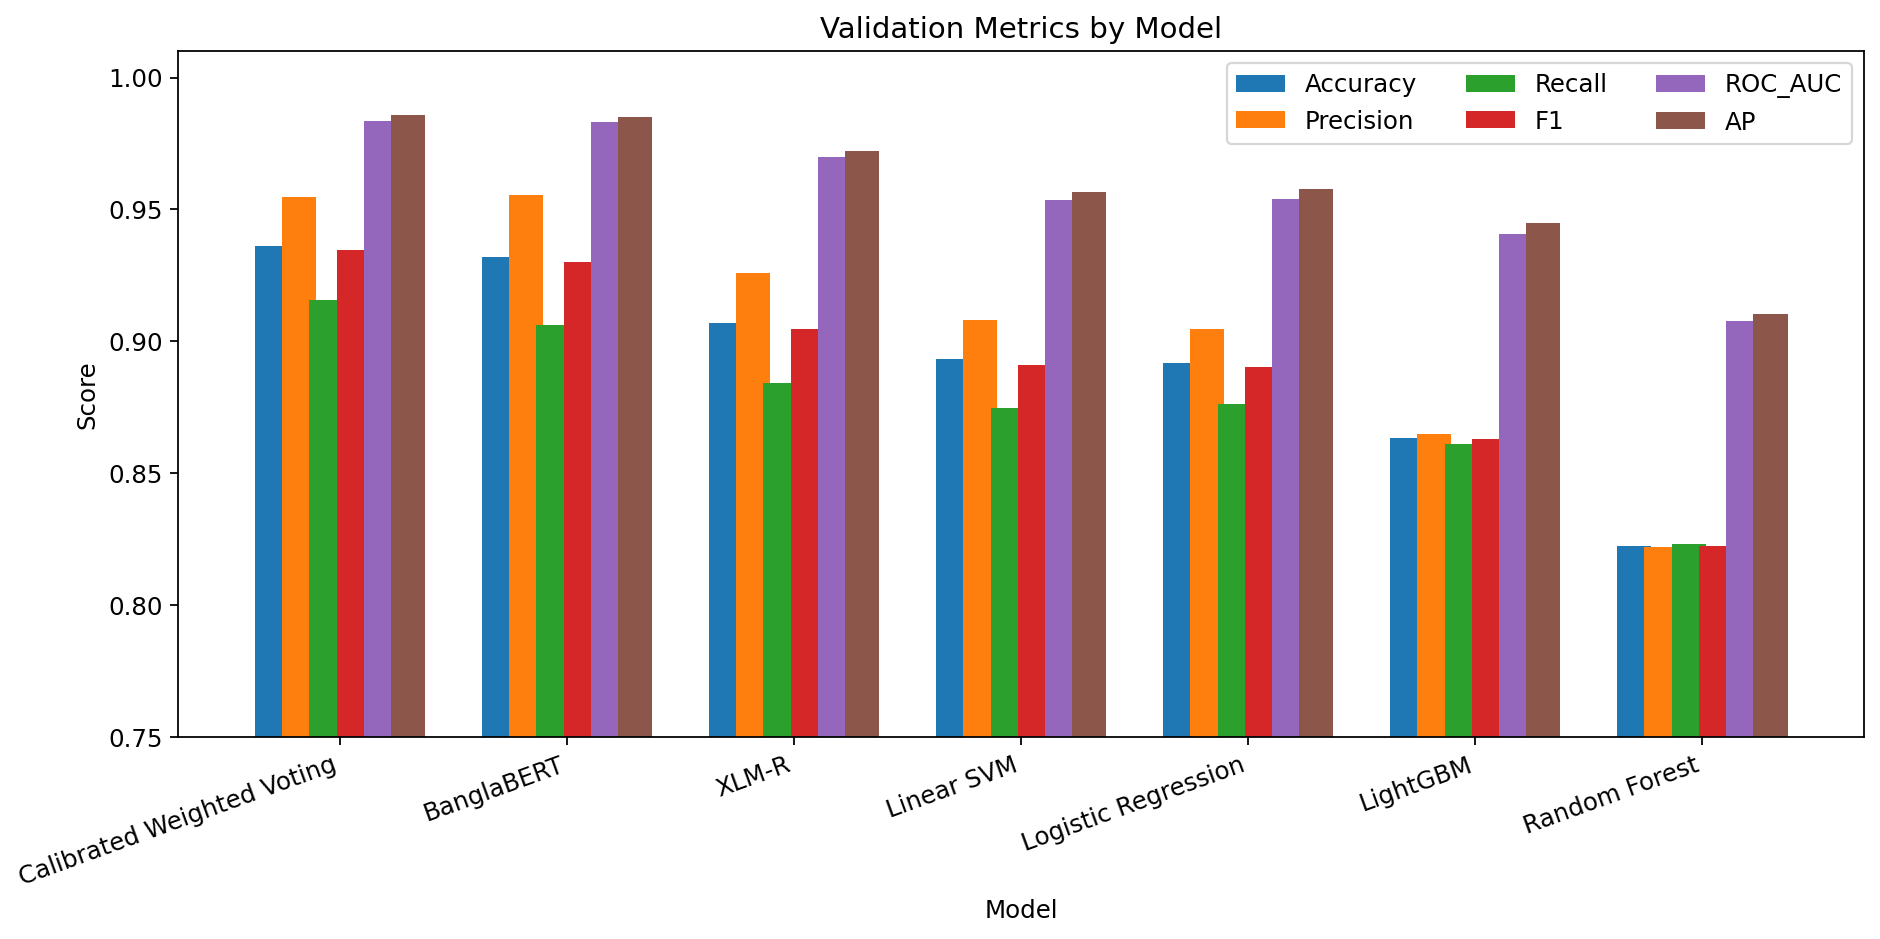

In [27]:
# 2) Grouped bar charts for core metrics
for split_name in ['Test', 'Validation']:
    df = get_split_df(split_name)
    x = np.arange(len(df))
    width = 0.15

    fig, ax = plt.subplots(figsize=(12, 6))
    offsets = np.linspace(-2, 2, len(plot_metrics)) * width
    for off, metric in zip(offsets, plot_metrics):
        ax.bar(x + off, df[metric], width=width, label=metric)

    ax.set_title(f'{split_name} Metrics by Model')
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(df['Model'], rotation=20, ha='right')
    ax.set_ylim(0.75, 1.01)
    ax.legend(ncol=3)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{split_name.lower()}_metrics_grouped_bar_chart.png', bbox_inches='tight')
    plt.show()

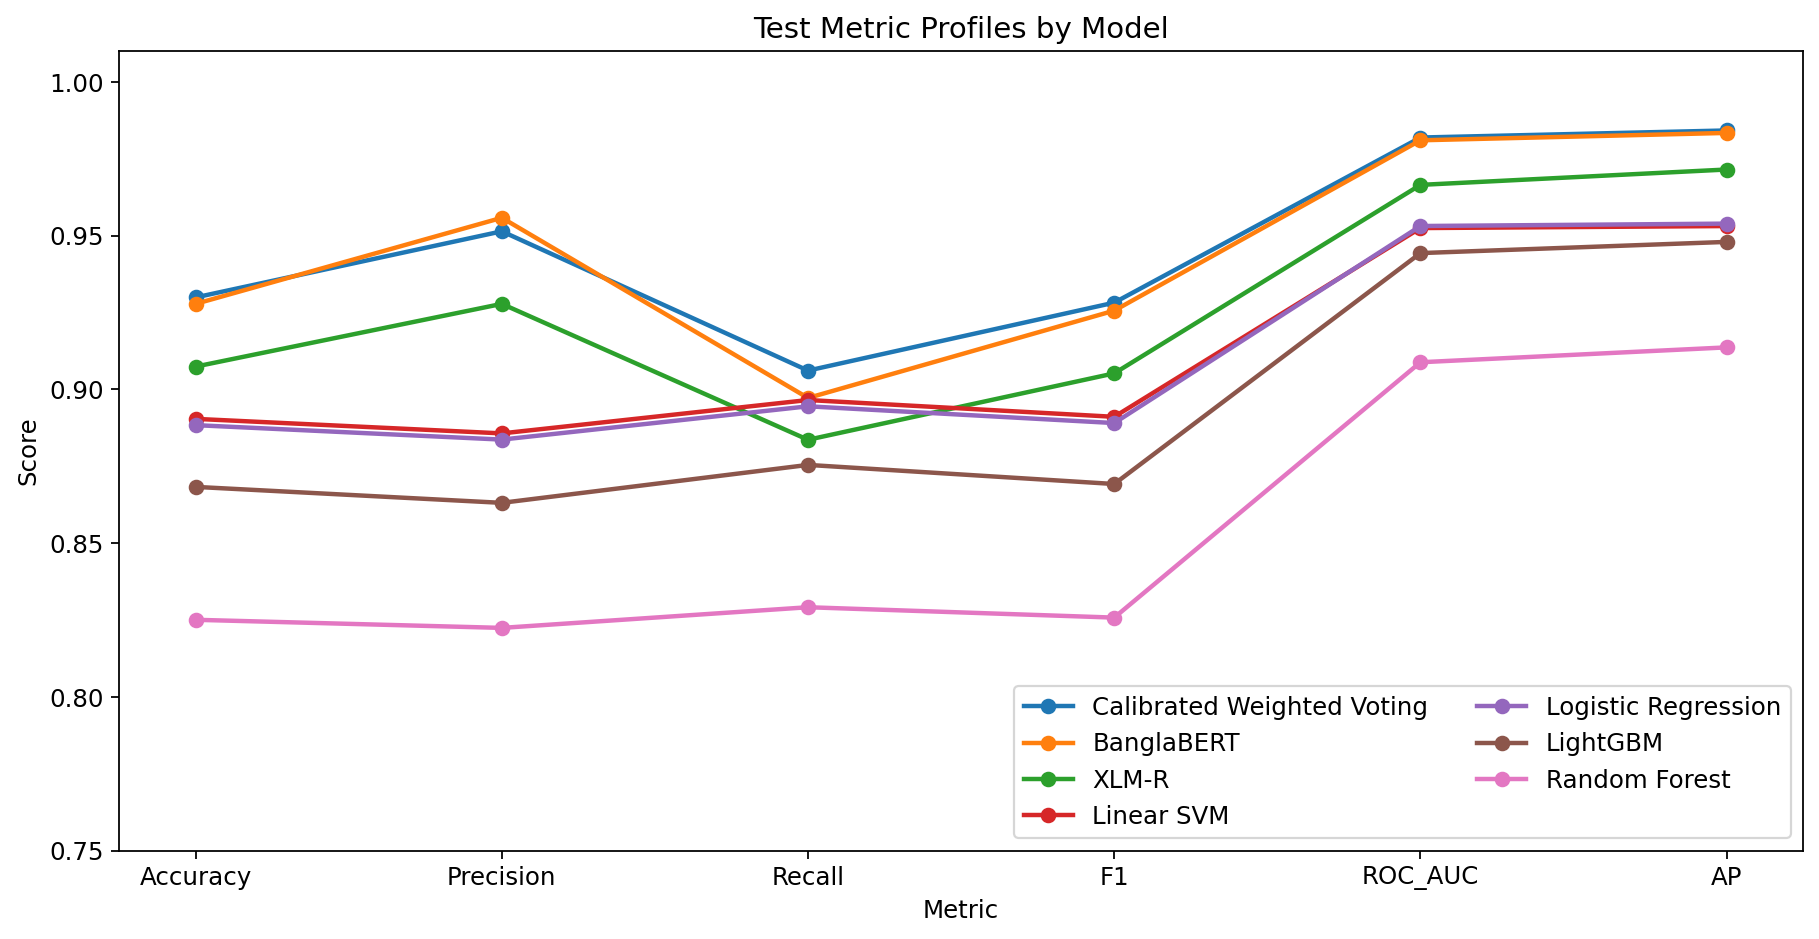

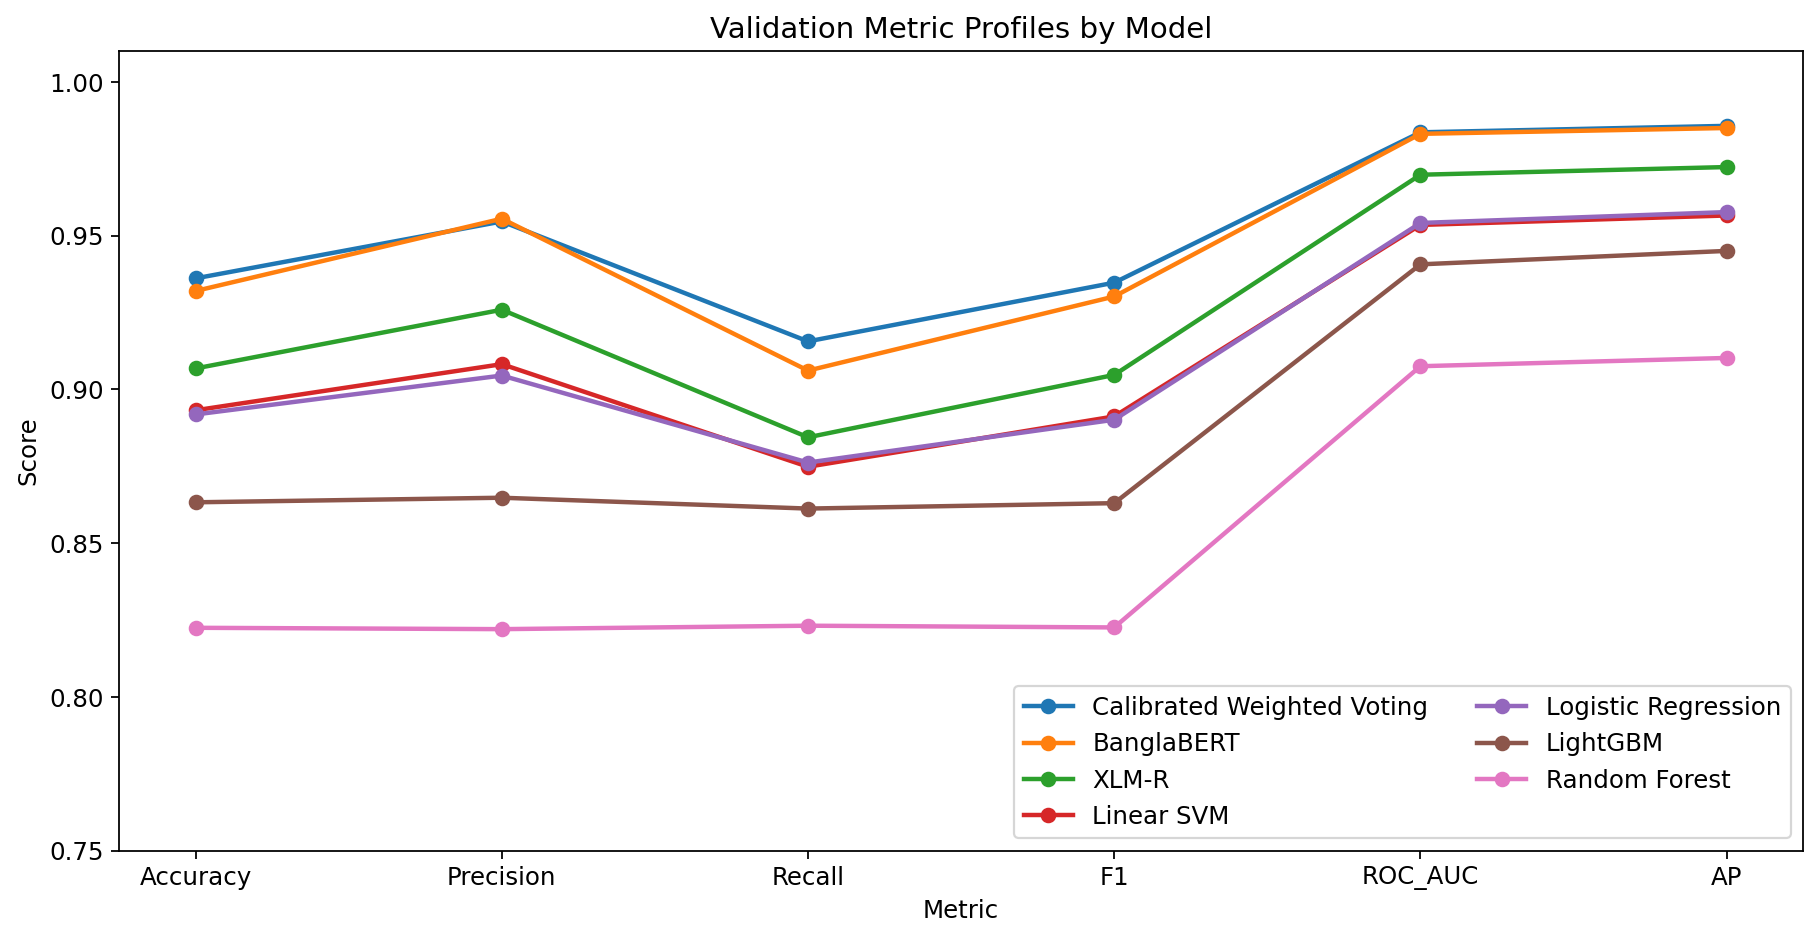

In [28]:
# 3) Metric profile line charts
for split_name in ['Test', 'Validation']:
    df = get_split_df(split_name)
    fig, ax = plt.subplots(figsize=(11.5, 6))
    for _, row in df.iterrows():
        ax.plot(plot_metrics, [row[m] for m in plot_metrics], marker='o', linewidth=2, label=row['Model'])

    ax.set_title(f'{split_name} Metric Profiles by Model')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_ylim(0.75, 1.01)
    ax.legend(loc='lower right', ncol=2)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{split_name.lower()}_metric_profile_line_chart.png', bbox_inches='tight')
    plt.show()

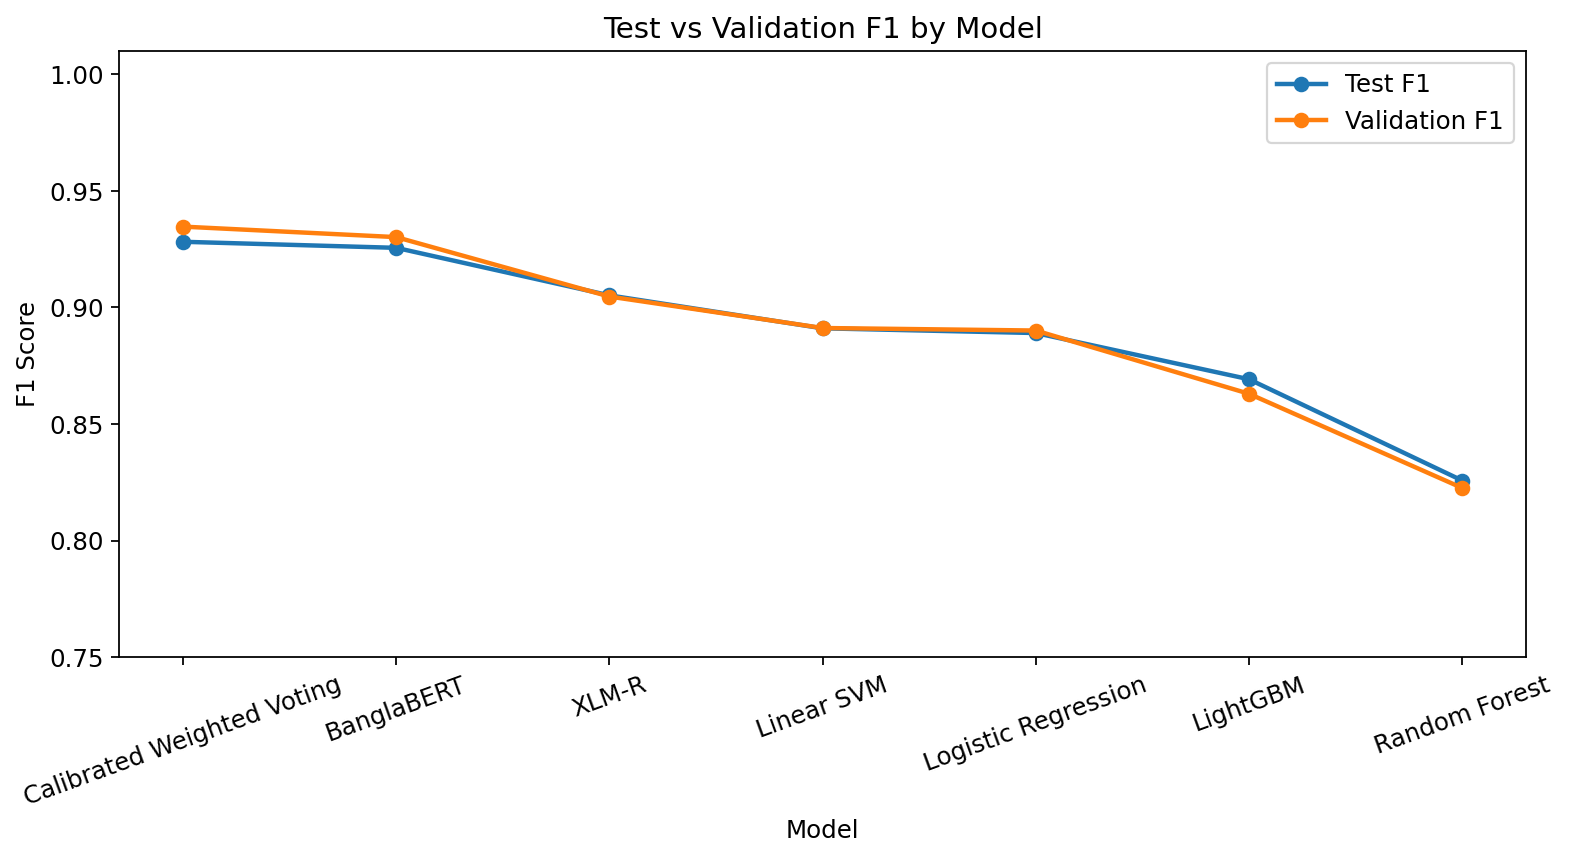

In [29]:
# 4) Split comparison line chart using F1 only
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = wide[['Model', 'Test_F1', 'Validation_F1']].copy()
plot_df = plot_df.sort_values('Test_F1', ascending=False)

ax.plot(plot_df['Model'], plot_df['Test_F1'], marker='o', linewidth=2, label='Test F1')
ax.plot(plot_df['Model'], plot_df['Validation_F1'], marker='o', linewidth=2, label='Validation F1')
ax.set_title('Test vs Validation F1 by Model')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.75, 1.01)
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'split_comparison_line_chart.png', bbox_inches='tight')
plt.show()

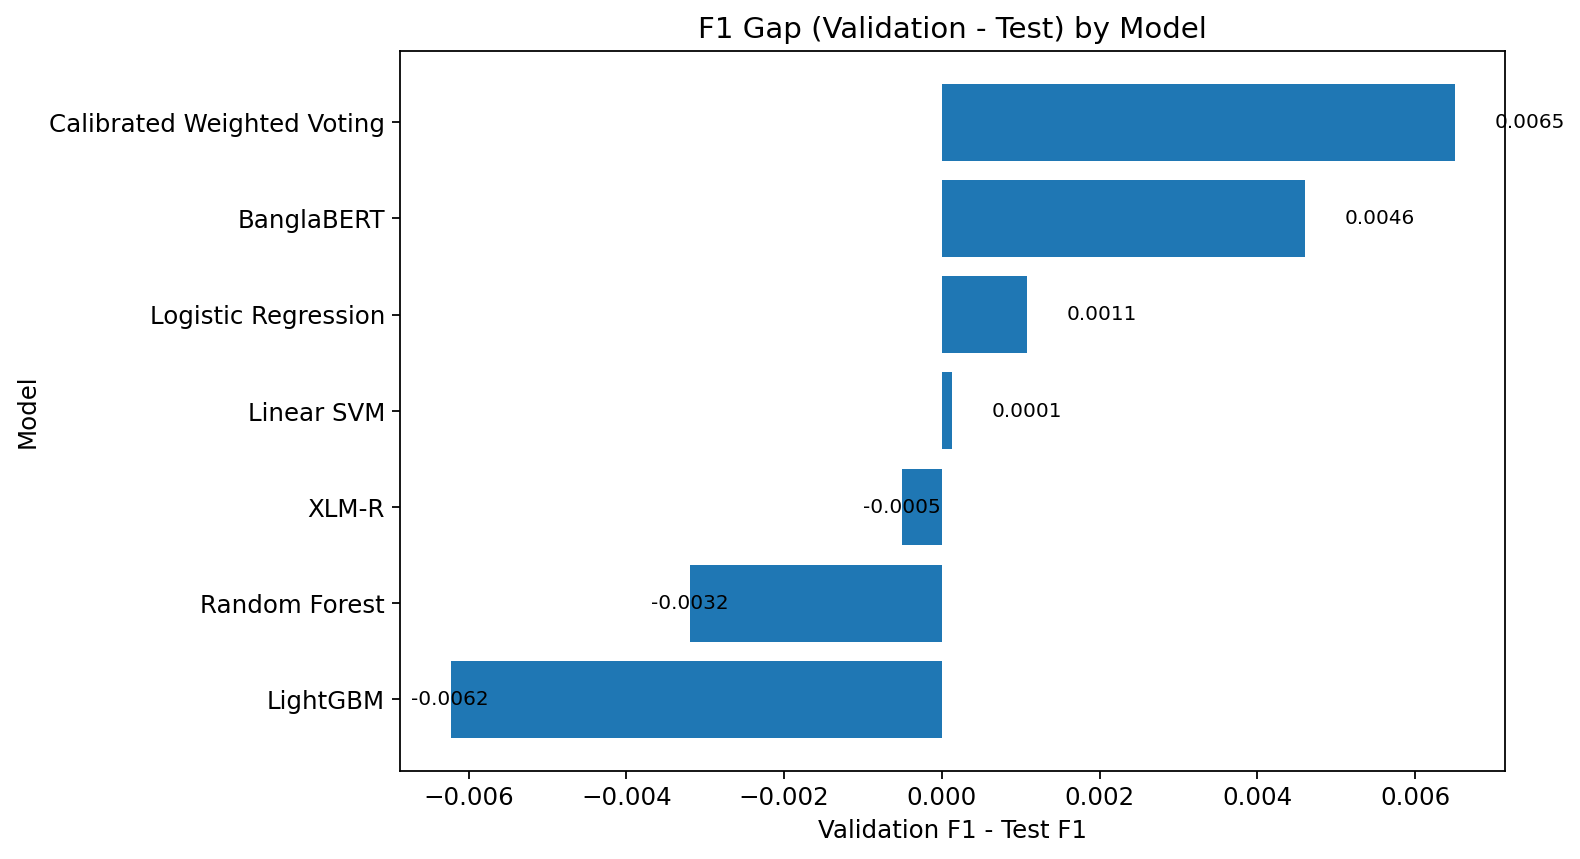

In [30]:
# 5) F1 gap bar chart (Validation - Test)
fig, ax = plt.subplots(figsize=(10, 5.5))
gap_df = comparison[['Model', 'F1_Gap_ValMinusTest']].sort_values('F1_Gap_ValMinusTest')
ax.barh(gap_df['Model'], gap_df['F1_Gap_ValMinusTest'])
ax.set_title('F1 Gap (Validation - Test) by Model')
ax.set_xlabel('Validation F1 - Test F1')
ax.set_ylabel('Model')
for i, v in enumerate(gap_df['F1_Gap_ValMinusTest']):
    ax.text(v + (0.0005 if v >= 0 else -0.0005), i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'f1_gap_bar_chart.png', bbox_inches='tight')
plt.show()

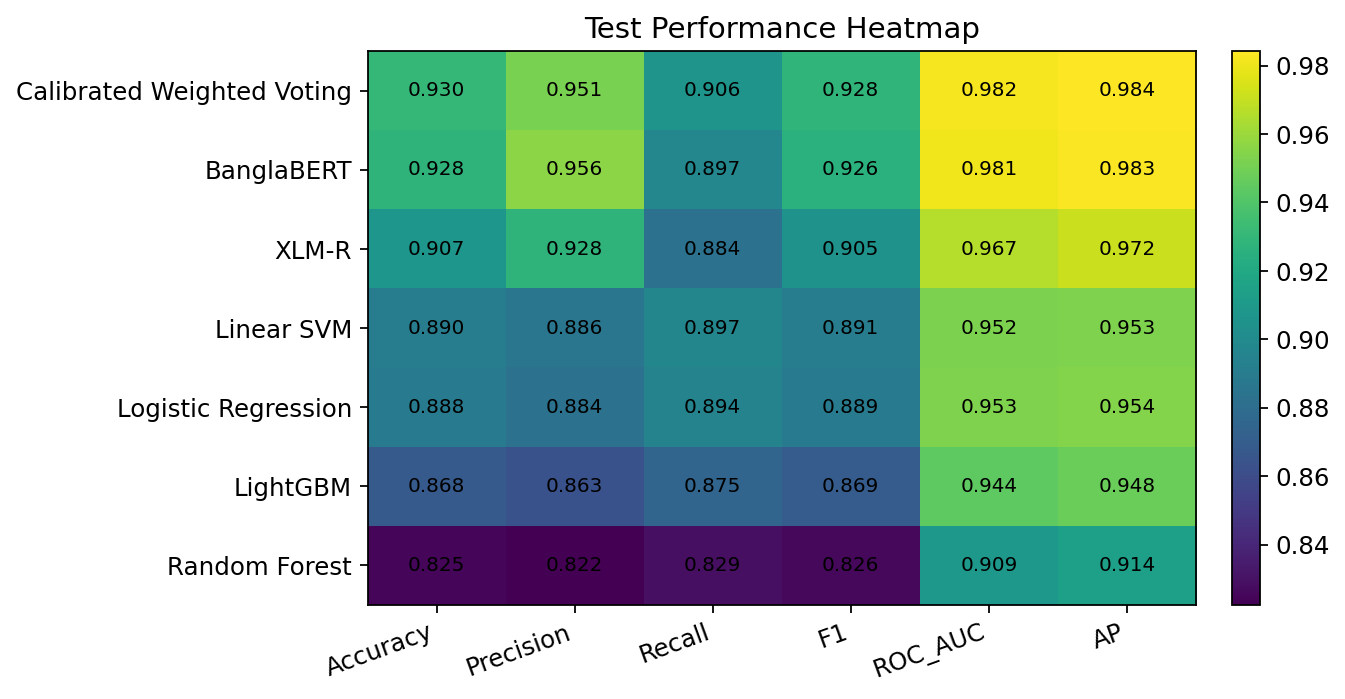

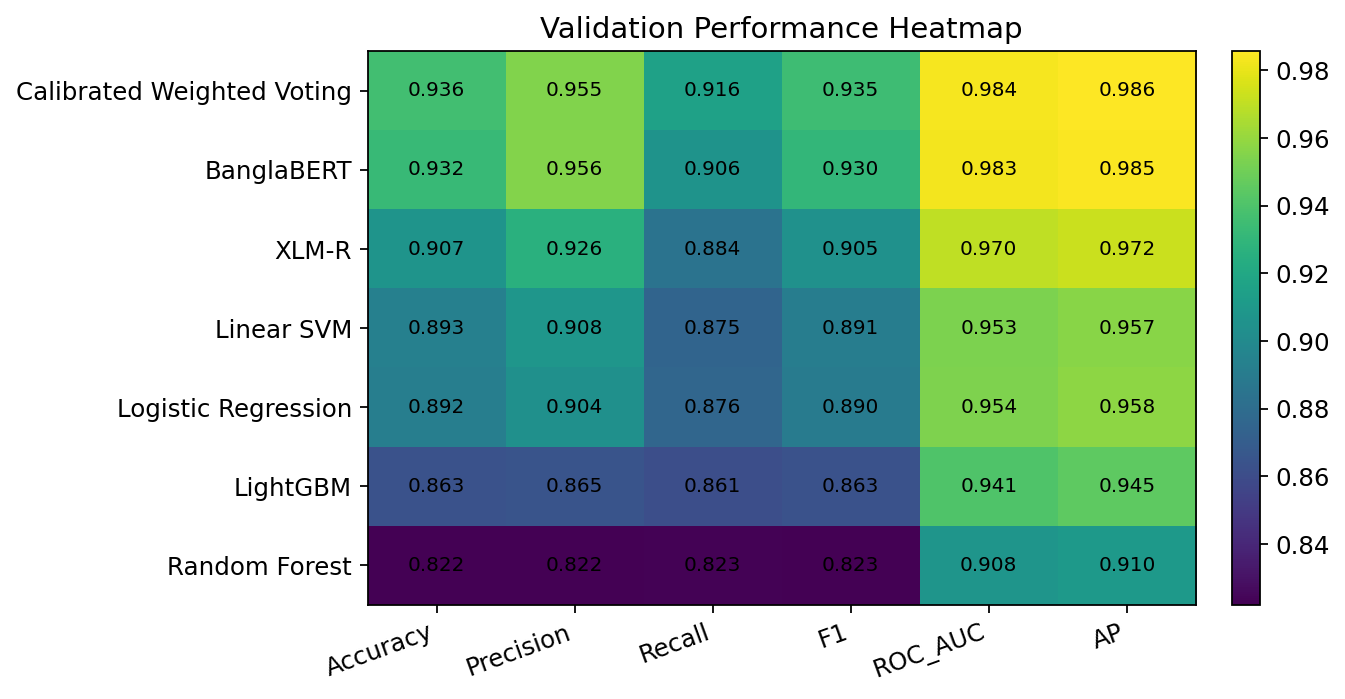

In [31]:
# 6) Heatmaps for test and validation tables
for split_name, df in [('Test', combined_test), ('Validation', combined_val)]:
    hm = df.set_index('Model')[plot_metrics]

    fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.6 * len(hm))))
    data = hm.values.astype(float)
    im = ax.imshow(data, aspect='auto')
    ax.set_title(f'{split_name} Performance Heatmap')
    ax.set_xticks(range(len(plot_metrics)))
    ax.set_xticklabels(plot_metrics, rotation=20, ha='right')
    ax.set_yticks(range(len(hm.index)))
    ax.set_yticklabels(hm.index)
    annotate_heatmap(ax, data, fmt='.3f')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{split_name.lower()}_performance_heatmap.png', bbox_inches='tight')
    plt.show()

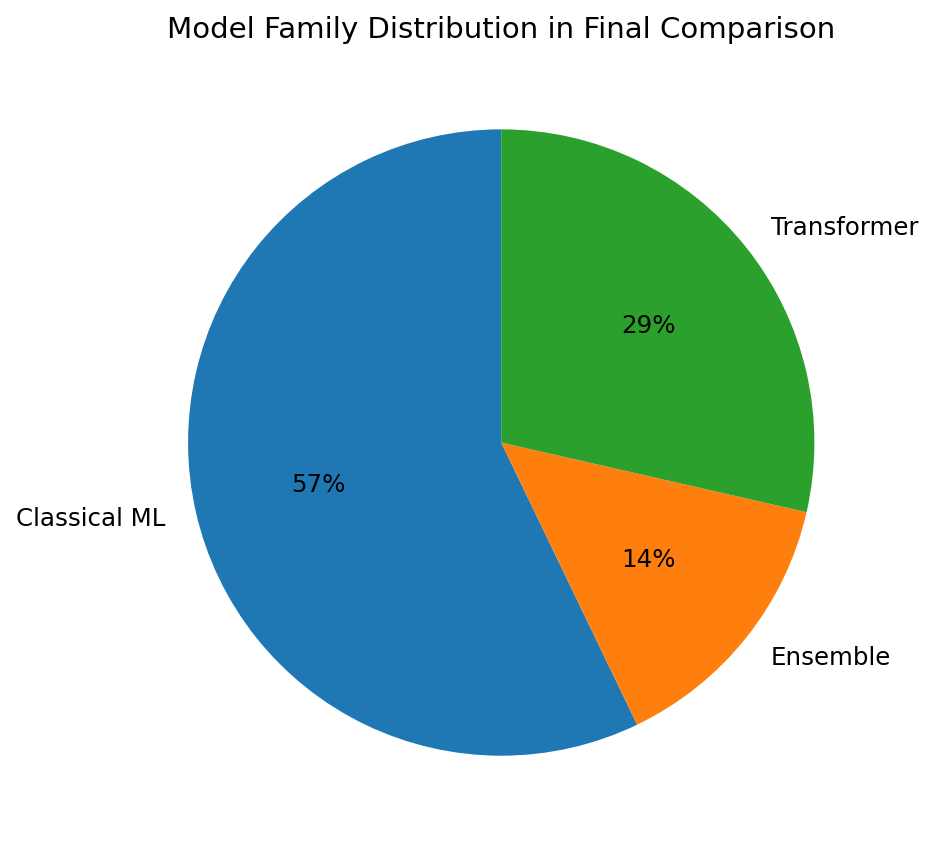

In [32]:
# 7) Pie chart for model family count
family_counts = combined_main[['Model', 'Model_Family']].drop_duplicates()['Model_Family'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(family_counts.values, labels=family_counts.index, autopct='%1.0f%%', startangle=90)
ax.set_title('Model Family Distribution in Final Comparison')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'model_family_distribution_pie_chart.png', bbox_inches='tight')
plt.show()

In [33]:
print('Saved files in output folder:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(p.name)

Saved files in output folder:
combined_main_results.csv
combined_summary_wide.csv
combined_test_results.csv
combined_validation_results.csv
f1_gap_bar_chart.png
model_family_distribution_pie_chart.png
split_comparison_line_chart.png
split_gap_analysis.csv
test_f1_bar_chart.png
test_metric_profile_line_chart.png
test_metrics_grouped_bar_chart.png
test_model_ranking.csv
test_performance_heatmap.png
validation_f1_bar_chart.png
validation_metric_profile_line_chart.png
validation_metrics_grouped_bar_chart.png
validation_model_ranking.csv
validation_performance_heatmap.png


In [34]:
# Optional: zip everything for download from Kaggle
zip_path = Path('/kaggle/working/final_combined_outputs.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_DIR.iterdir():
        zf.write(p, arcname=p.name)

print('ZIP created:', zip_path)

ZIP created: /kaggle/working/final_combined_outputs.zip
